#**Análisis Predictivo de Rotación Laboral mediante Machine Learning**

##Objetivo general: Predecir qué empleados tienen más probabilidad de dejar la empresa

##Objetivos específicos:

1.   Analizar los factores más influyentes en la rotación
2.   Comparar distintos algoritmos de ML para evaluar su desempeño
3.   Interpretar los resultados para generar recomendaciones que reduzcan la rotación



##Justificación

*   Se invierte una gran cantidad de dinero y tiempo a la hora de contratar y retener empleados
*   La empresa no tiene claro si hay un perfil claro de empleados que puedan estar en riesgo de renunciar
*   Intentaremos reducir la cantidad de esfuerzos para encontrar al candidato o candidata ideal para el puesto



#TFM PARTE I: Procesamiento de los datos

En primer lugar cargaremos todas las bibliotecas que vamos a necesitar

In [ ]:
# Importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Importamos archivo csv (dataset de la empresa)
df = pd.read_csv('empleados.csv', encoding='ISO-8859-1')

#1. Análisis exploratorio de los datos

In [ ]:
# Revisamos los primeros datos de nuestro dataset
df.head()

,Referencia,Perfil,Género,Jornada laboral,Equipo,Ubicación,Nivel Estudios,Estado Civil,Fecha Nacimiento,Edad,Antigüedad,Fecha Fin,Años en Empresa,Grupo Profesional,Salario mensual,Categoria,Distancia al trabajo (KM),Promociones,Nivel de satisfacción
0,TRB-0000002,Activo,Hombre,COMPLETA,SEVILLA,ESPAÑA,Bachillerato,CASADO,08/01/1979,46.0,01/06/2000,NaN,25.0,GRUPO 1 (CTD),3617.0,DIRECCION,10,3,4
1,TRB-0000005,No activo,Mujer,COMPLETA,SEVILLA,ESPAÑA,Máster,CASADO,04/09/1977,48.0,14/02/2011,02/02/2022,10.0,GRUPO 2.1 (R),2562.0,RESPONSABLE DE AREA,14,2,2
2,TRB-0000007,Activo,Mujer,COMPLETA,ADMINISTRACION,ESPAÑA,Máster,CASADO,02/11/1975,50.0,01/10/2001,NaN,24.0,GRUPO 1 (ADRREE),3605.0,DIRECCION,6,3,3
3,TRB-0000008,Activo,Mujer,COMPLETA,ORIENTE MEDIO,EXPATRIADO,Grado Universitario,SOLTERO/A,07/03/1975,50.0,24/04/2001,NaN,24.0,GRUPO 1 (CTD),3696.0,DIRECCION,8,3,3
4,TRB-0000009,Activo,Mujer,COMPLETA,MADRID,ESPAÑA,Máster,SOLTERO/A,20/09/1977,48.0,24/01/2001,NaN,24.0,GRUPO 1 (R),3228.0,REFERENTES,9,3,3


In [ ]:
# Inspección rápida de nuestros datos -> Comprobación de tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Referencia                 223 non-null    object 
 1   Perfil                     223 non-null    object 
 2   Género                     223 non-null    object 
 3   Jornada laboral            223 non-null    object 
 4   Equipo                     223 non-null    object 
 5   Ubicación                  223 non-null    object 
 6   Nivel Estudios             223 non-null    object 
 7   Estado Civil               221 non-null    object 
 8   Fecha Nacimiento           220 non-null    object 
 9   Edad                       221 non-null    float64
 10  Antigüedad                 218 non-null    object 
 11  Fecha Fin                  125 non-null    object 
 12  Años en Empresa            218 non-null    float64
 13  Grupo Profesional          212 non-null    object 

In [ ]:
# Eliminamos las variables que no nos resultarán útil para nuestro análisis de predicción
df.drop(['Fecha Nacimiento', 'Antigüedad', 'Fecha Fin'], axis=1, inplace=True)

#1.1 Análisis inicial de variables númericas

In [ ]:
# Análisis inicial de variables numéricas (habrá que realizarlo de nuevo despues de los ajustes)
df.describe()

,Edad,Años en Empresa,Salario mensual,Distancia al trabajo (KM),Promociones,Nivel de satisfacción
count,221.000000,218.000000,212.000000,223.000000,223.000000,223.000000
mean,40.294118,3.779817,2321.863208,11.681614,0.991031,2.735426
std,14.325102,5.661508,456.542513,4.728862,1.073812,0.898924
min,25.000000,0.000000,108.000000,1.000000,0.000000,1.000000
25%,32.000000,0.000000,2012.000000,8.000000,0.000000,2.000000
50%,37.000000,2.000000,2195.000000,11.000000,1.000000,3.000000
75%,46.000000,5.000000,2498.750000,16.000000,2.000000,3.000000
max,125.000000,26.000000,4528.000000,20.000000,4.000000,4.000000


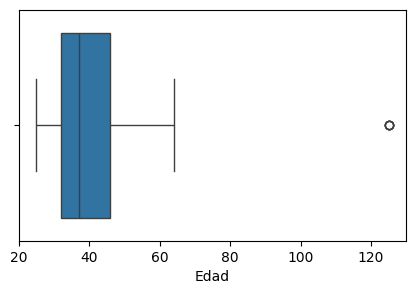

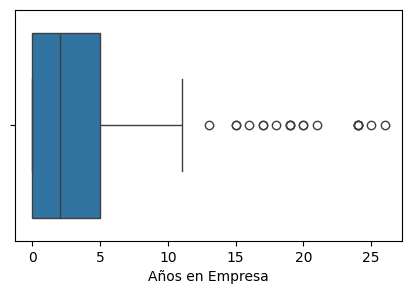

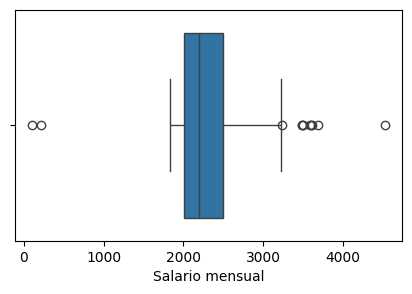

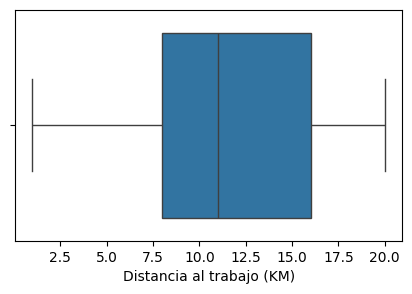

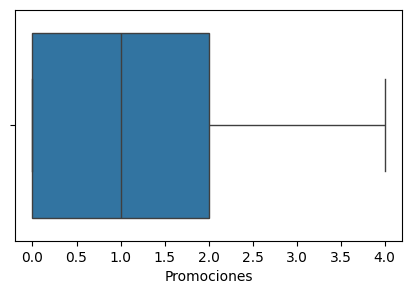

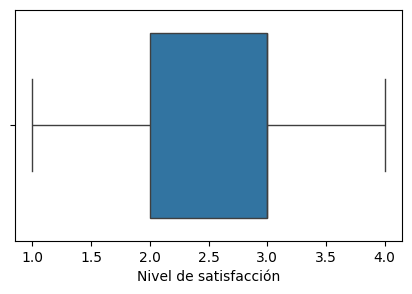

In [ ]:
# Visualizamos las distribuciones de varibales numéricas
for c in df.select_dtypes(np.number).columns:
    plt.figure(figsize=(5, 3))
    sns.boxplot(data=df, x=c)
    plt.show()

### Conclusiones: comprobamos en el box plot de la Edad que existe un valor anómalo (outlier), es así porque no puede haber una persona con más de 120 años. Luego lo trataremos. Estamos en fase de identificación

#1.2 Análisis inicial de variables categoricas

In [ ]:
import matplotlib.pyplot as plt
from math import ceil

def graficos_eda_categoricos(df, variables_categoricas):
    # Filtramos solo las variables categóricas seleccionadas que estén en el DataFrame
    variables = [var for var in variables_categoricas if var in df.columns]

    # Calculamos el número de filas necesarias (2 gráficos por fila)
    filas = ceil(len(variables) / 2)

    # Definimos la figura
    fig, ax = plt.subplots(nrows=filas, ncols=2, figsize=(16, filas * 6))
    ax = ax.flat  # Aplanamos para iterar fácilmente

    # Creamos los gráficos
    for indice, variable in enumerate(variables):
        df[variable].value_counts().plot.barh(ax=ax[indice])
        ax[indice].set_title(variable, fontsize=12, fontweight="bold")
        ax[indice].tick_params(labelsize=12)

    # Ocultamos ejes sobrantes si no son necesarios
    for i in range(len(variables), len(ax)):
        fig.delaxes(ax[i])

    plt.tight_layout()
    plt.show()


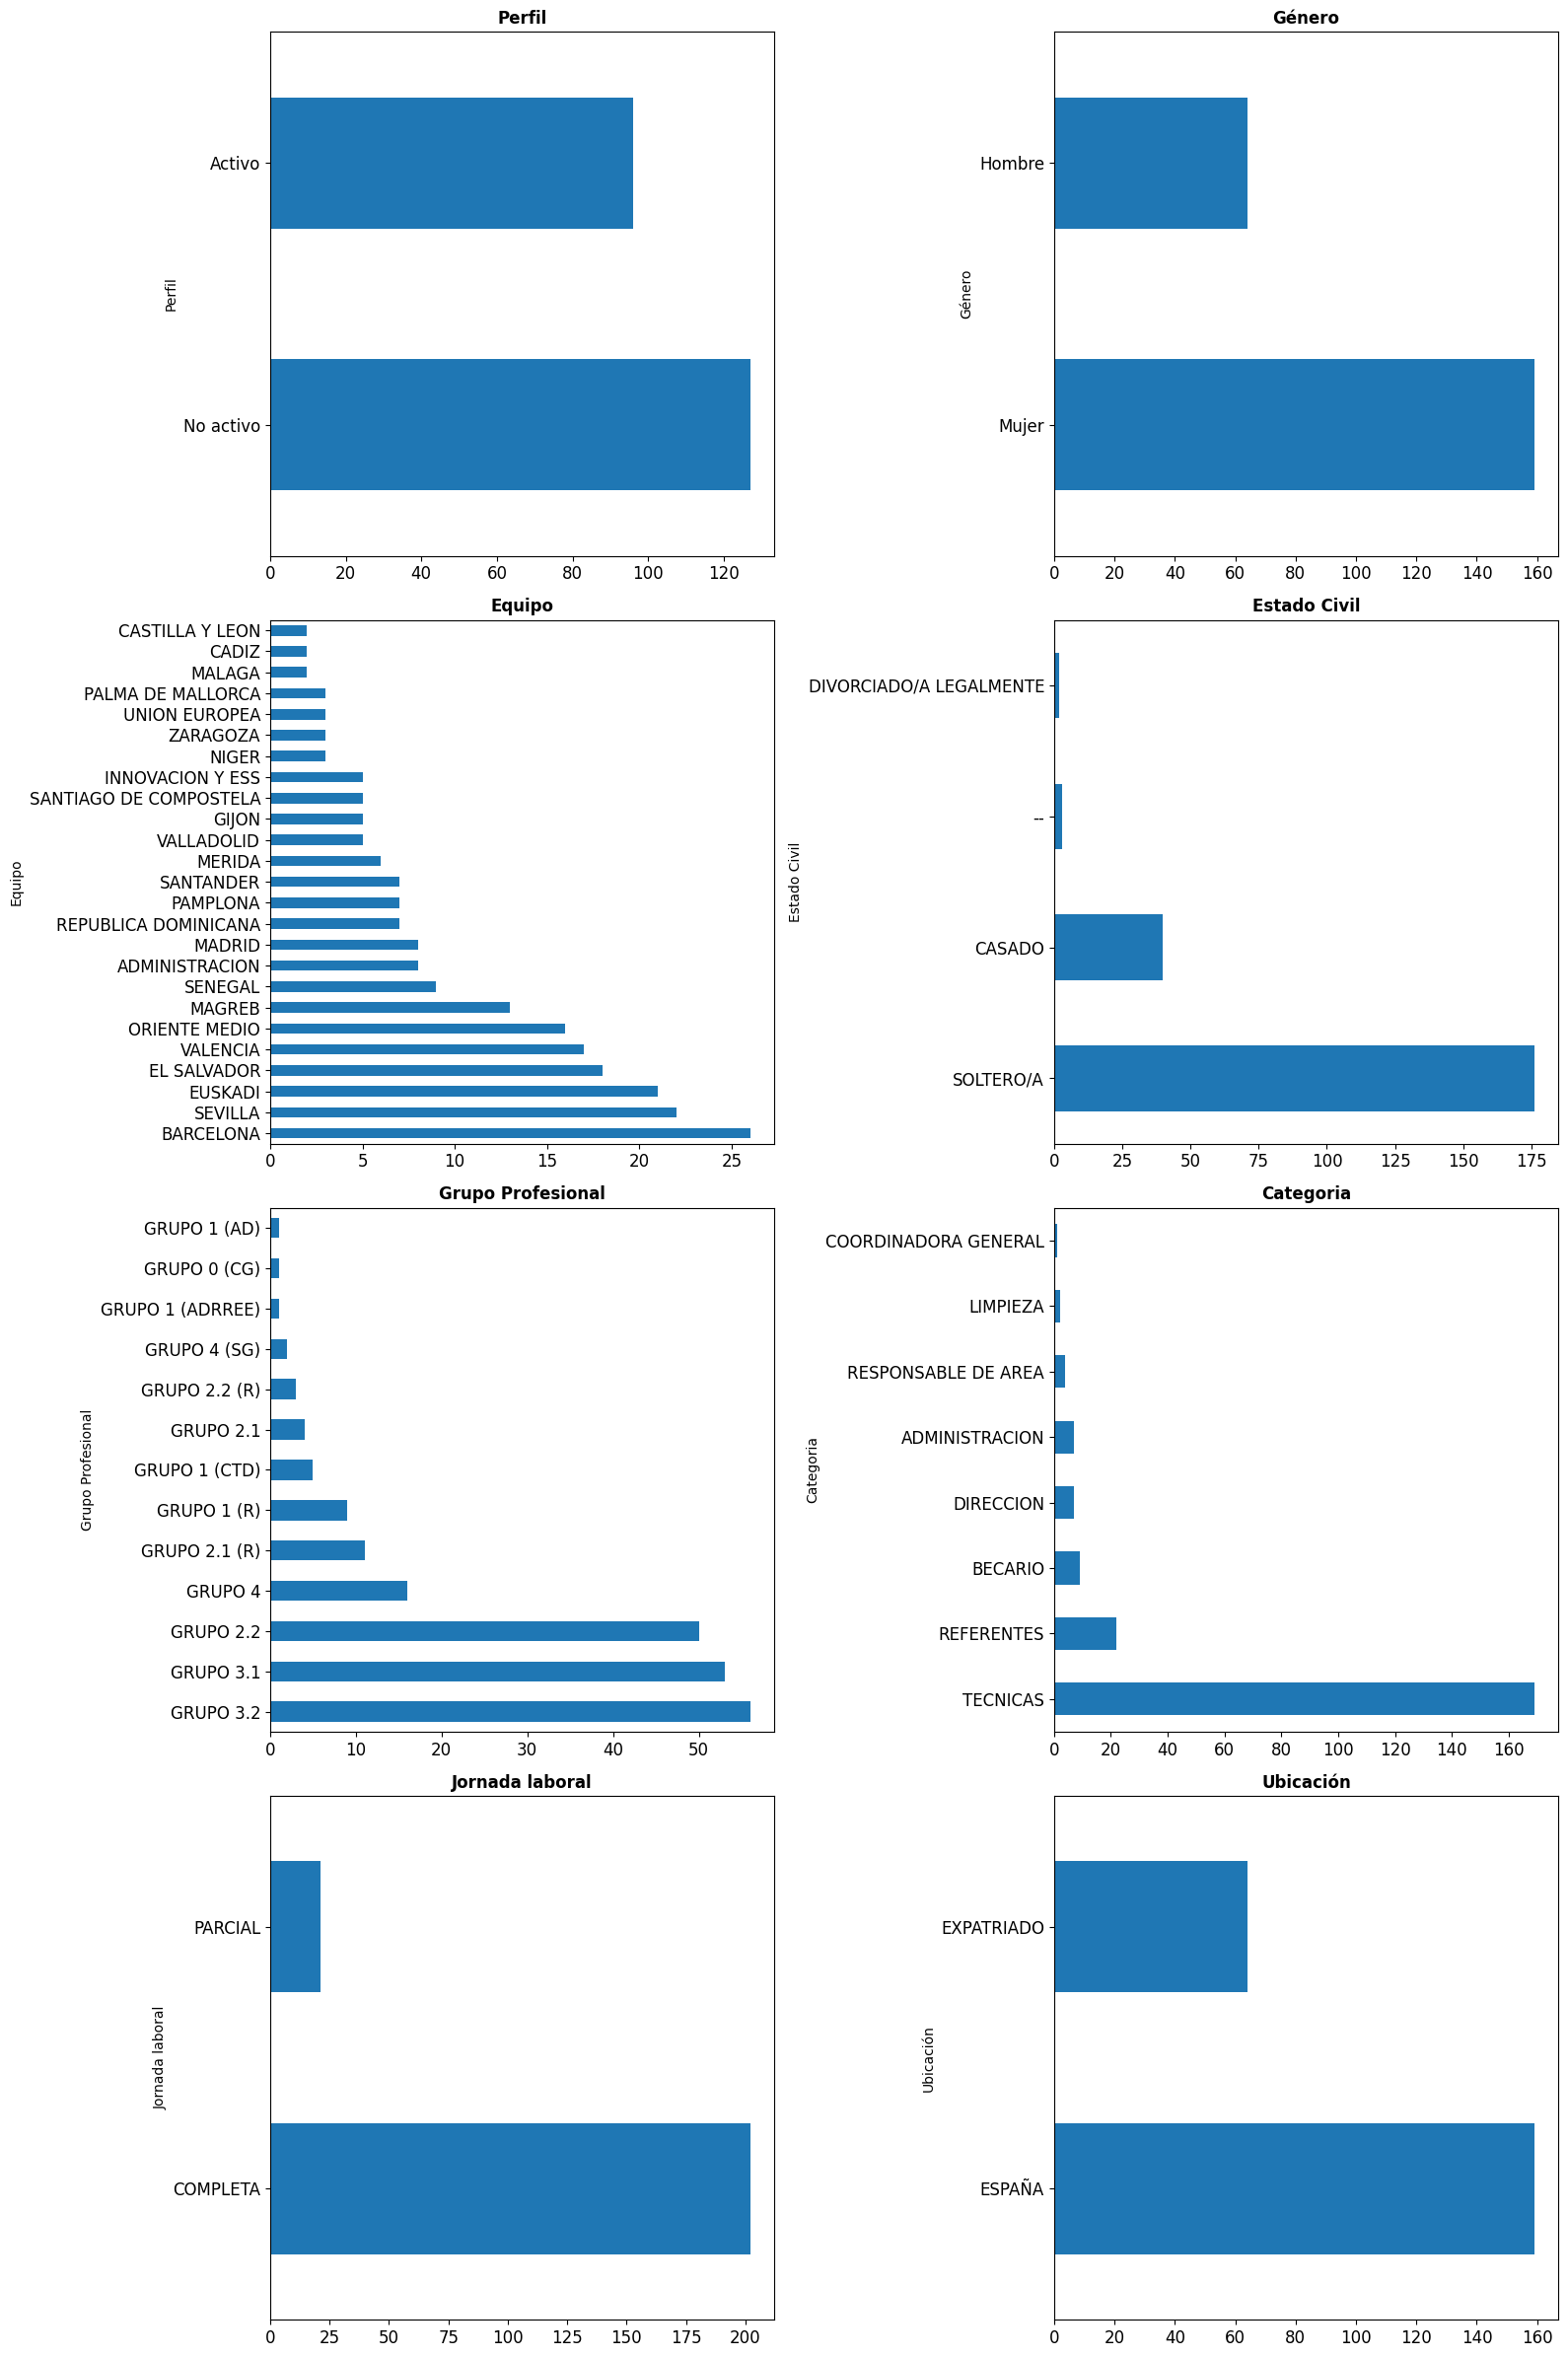

In [ ]:
variables_categoricas = ['Perfil', 'Género', 'Equipo', 'Estado Civil', 'Grupo Profesional', 'Categoria', 'Jornada laboral', 'Ubicación']
graficos_eda_categoricos(df, variables_categoricas)


###Conlusiones: Observamos en el gráfico del Estado Civil, hay valores nulos. Luego lo trataremos

#2. Transformaciones y ajustes de variables

In [ ]:
# Empezamos modificando el nombre de algunas columnas del dataseet
df = df.rename(columns={
    'Perfil': 'perfil',
    'Género': 'genero',
    'Jornada laboral': 'jornada',
    'Equipo': 'equipo',
    'Ubicación': 'ubicacion',
    'Nivel Estudios': 'nivel_estudios',
    'Estado Civil': 'estado_civil',
    'Edad': 'edad',
    'Años en Empresa': 'antiguedad_empresa',
    'Grupo Profesional': 'grupo_profesional',
    'Salario mensual': 'salario_mensual',
    'Categoria': 'departamento',
    'Distancia al trabajo (KM)': 'distancia_trabajo_km',
    'Promociones': 'promociones',
    'Nivel de satisfacción': 'satisfaccion'
})


##2.1 Reducción de la dimensionalidad

##Convertimos las variables 'nivel_estudios' y 'grupo_profesional' en variables númericas.
###Se realiza estas transformaciones ya que al ser valores que guardan una relación de distancia entre ellos, podríamos codificarlos como variables númericas. Se le asigna un valor 0 a quienes tengan estudios menos cualificados y estén asignados al menor grupo salarial o profesional. Y, viceversa, se le asigna los mayores valores a lo contrario.

In [ ]:
estudios_mapper = {
    'ESO': 0,
    'Bachillerato':1,
    'Grado Superior': 2,
    'Grado Universitario': 3,
    'Máster': 4,
    'Doctorado': 5
}

grupo_mapper = {
    'GRUPO 4 (SG)': 0,
    'GRUPO 4': 1,
    'GRUPO 3.2': 2,
    'GRUPO 3.1': 3,
    'GRUPO 2.2': 4,
    'GRUPO 2.2 (R)': 4,
    'GRUPO 2.1': 5,
    'GRUPO 2.1 (R)': 5,
    'GRUPO 1 (CTD)': 6,
    'GRUPO 1 (ADRREE)': 6,
    'GRUPO 1 (R)': 6,
    'GRUPO 1': 7,
    'GRUPO 0 (CG)': 8
}



df['nivel_estudios'] = df['nivel_estudios'].map(estudios_mapper)
df['grupo_profesional'] = df['grupo_profesional'].map(grupo_mapper)


df.head()

,Referencia,perfil,genero,jornada,equipo,ubicacion,nivel_estudios,estado_civil,edad,antiguedad_empresa,grupo_profesional,salario_mensual,departamento,distancia_trabajo_km,promociones,satisfaccion
0,TRB-0000002,Activo,Hombre,COMPLETA,SEVILLA,ESPAÑA,1.0,CASADO,46.0,25.0,6.0,3617.0,DIRECCION,10,3,4
1,TRB-0000005,No activo,Mujer,COMPLETA,SEVILLA,ESPAÑA,4.0,CASADO,48.0,10.0,5.0,2562.0,RESPONSABLE DE AREA,14,2,2
2,TRB-0000007,Activo,Mujer,COMPLETA,ADMINISTRACION,ESPAÑA,4.0,CASADO,50.0,24.0,6.0,3605.0,DIRECCION,6,3,3
3,TRB-0000008,Activo,Mujer,COMPLETA,ORIENTE MEDIO,EXPATRIADO,3.0,SOLTERO/A,50.0,24.0,6.0,3696.0,DIRECCION,8,3,3
4,TRB-0000009,Activo,Mujer,COMPLETA,MADRID,ESPAÑA,4.0,SOLTERO/A,48.0,24.0,6.0,3228.0,REFERENTES,9,3,3


## 2.2 Gestionamos valores nulos y campos vacios

In [ ]:
# Calculamos el número de nulos por cada columna
num_nulls = df.isnull().sum()

# Calculamos el porcentaje de nulos por cada columna
percent_nulls = (num_nulls / len(df)) * 100

# Create a new dataframe to summarize the information
null_summary_df = pd.DataFrame({
    'Number of Nulls': num_nulls,
    'Percentage': percent_nulls
})
# Round the percentage to two decimal places for better readability
null_summary_df['Percentage'] = null_summary_df['Percentage'].round(2)

# Display the summary dataframe
print(null_summary_df)

                      Number of Nulls  Percentage
Referencia                          0        0.00
perfil                              0        0.00
genero                              0        0.00
jornada                             0        0.00
equipo                              0        0.00
ubicacion                           0        0.00
nivel_estudios                      6        2.69
estado_civil                        2        0.90
edad                                2        0.90
antiguedad_empresa                  5        2.24
grupo_profesional                  12        5.38
salario_mensual                    11        4.93
departamento                        2        0.90
distancia_trabajo_km                0        0.00
promociones                         0        0.00
satisfaccion                        0        0.00


<Axes: >

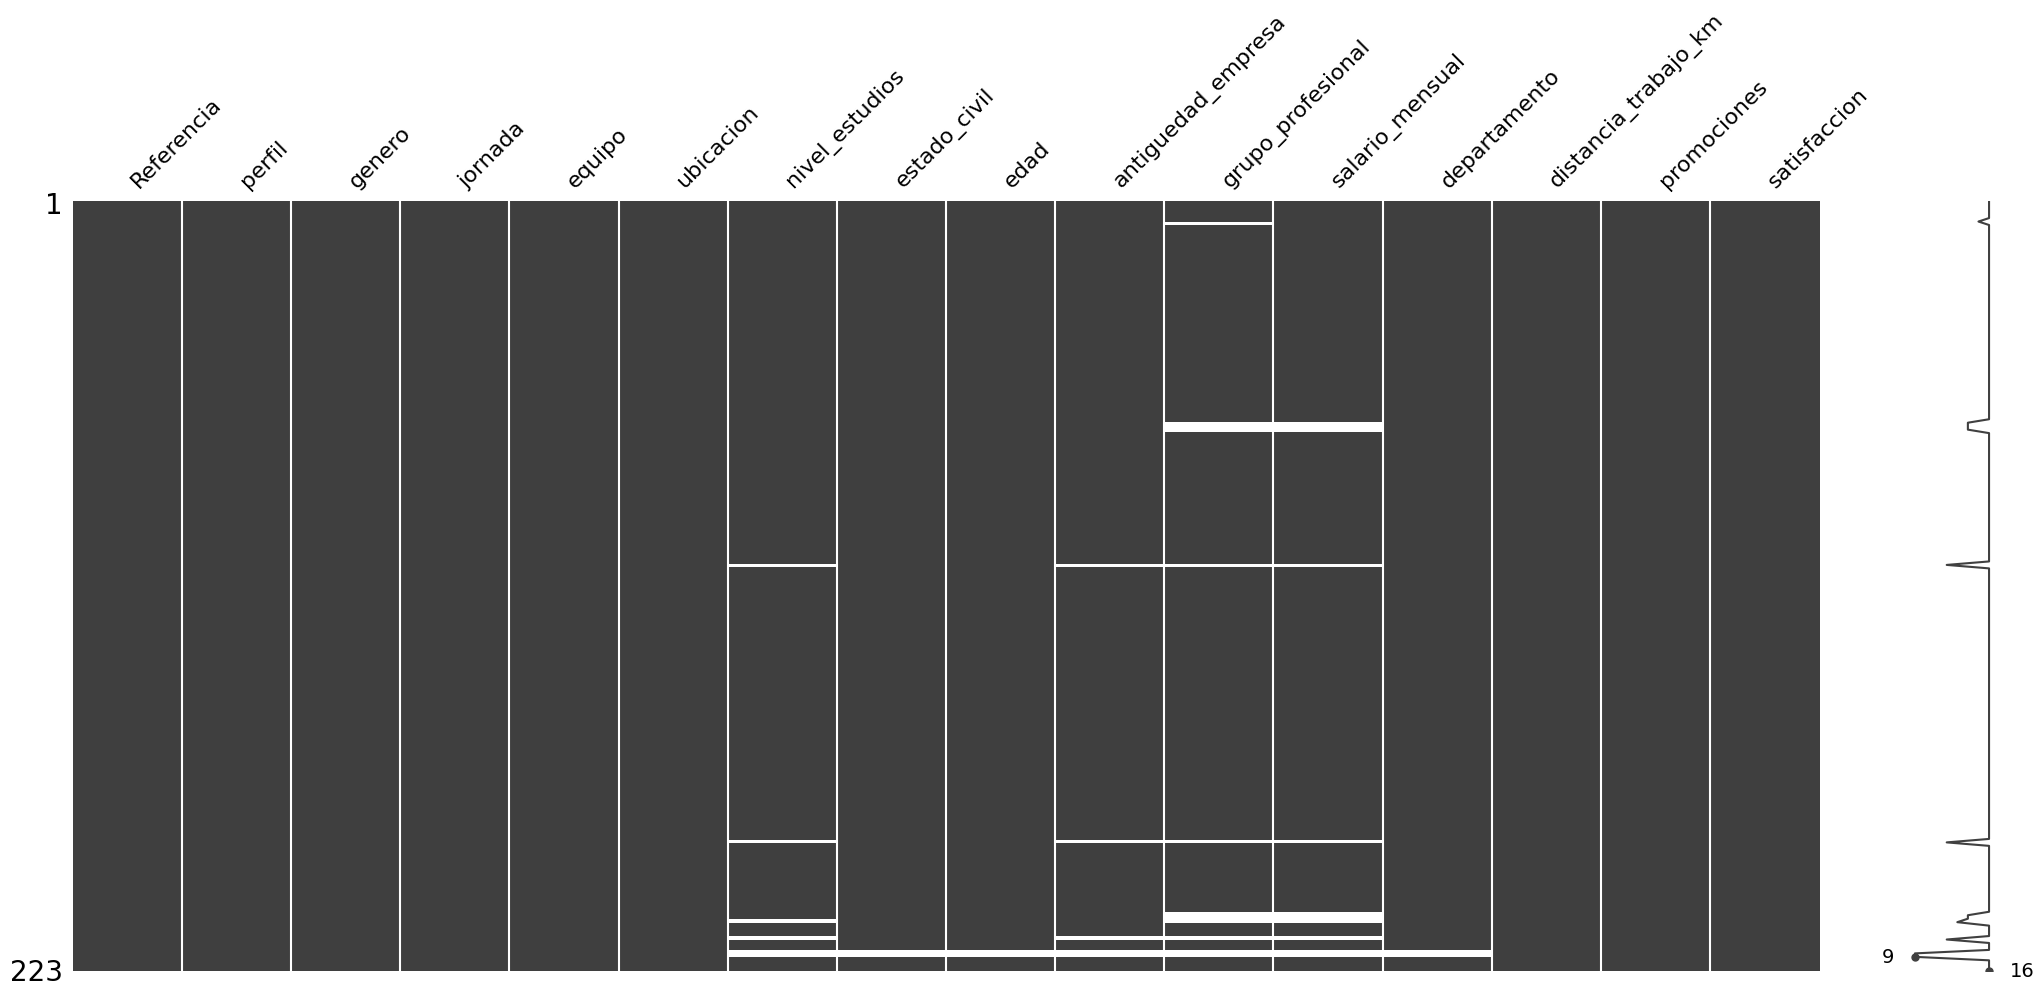

In [ ]:
# Visualizamos los datos faltantes (valores nulos) usando la biblioteca missigno
import missingno as msno
msno.matrix(df)

In [ ]:
df.departamento.unique()

array(['DIRECCION', 'RESPONSABLE DE AREA', 'REFERENTES',
       'COORDINADORA GENERAL', 'ADMINISTRACION', 'TECNICAS', 'LIMPIEZA',
       'BECARIO', nan], dtype=object)

In [ ]:
# Eliminamos todas las filas que contienen la categoria 'BECARIO' porque detectamos que son las personas que no tienen todos los datos completos
df.replace('BECARIO', np.nan, inplace=True)
df = df.dropna()

In [ ]:
# Comprobamos que no quedan valores nulos
df.isnull().sum()

,0
Referencia,0
perfil,0
genero,0
jornada,0
equipo,0
ubicacion,0
nivel_estudios,0
estado_civil,0
edad,0
antiguedad_empresa,0


###2.3 Ajustamos los tipos de variables

In [ ]:
# Hacemos una copia de nuestro dataseet
df_procesado = df.copy()

In [ ]:
# Convertimos las variables que tienen decimales a enteros
df_procesado['edad'] = df_procesado['edad'].astype(int)
df_procesado['antiguedad_empresa'] = df_procesado['antiguedad_empresa'].astype(int)
df_procesado['salario_mensual'] = df_procesado['salario_mensual'].astype(int)
#df_procesado['nivel_estudios'] = df_procesado['nivel_estudios'].astype(int)
#df_procesado['grupo_profesional'] = df_procesado['grupo_profesional'].astype(int)
#df_ajuste['categoria'] = df_ajuste['categoria'].astype(int)

In [ ]:
# Reemplazamos las columnas 'perfil', 'genero', 'jornada', 'ubicacion' por números binarios (0, 1)
df_procesado['perfil'] = df_procesado['perfil'].apply(lambda x: 1 if x == 'Activo' else 0)
df_procesado['genero'] = df_procesado['genero'].apply(lambda x: 1 if x == 'Hombre' else 0)
df_procesado['jornada'] = df_procesado['jornada'].apply(lambda x: 1 if x == 'COMPLETA' else 0)
df_procesado['ubicacion'] = df_procesado['ubicacion'].apply(lambda x: 1 if x == 'ESPAÑA' else 0)

In [ ]:
df_procesado

,Referencia,perfil,genero,jornada,equipo,ubicacion,nivel_estudios,estado_civil,edad,antiguedad_empresa,grupo_profesional,salario_mensual,departamento,distancia_trabajo_km,promociones,satisfaccion
0,TRB-0000002,1,1,1,SEVILLA,1,1.0,CASADO,46,25,6.0,3617,DIRECCION,10,3,4
1,TRB-0000005,0,0,1,SEVILLA,1,4.0,CASADO,48,10,5.0,2562,RESPONSABLE DE AREA,14,2,2
2,TRB-0000007,1,0,1,ADMINISTRACION,1,4.0,CASADO,50,24,6.0,3605,DIRECCION,6,3,3
3,TRB-0000008,1,0,1,ORIENTE MEDIO,0,3.0,SOLTERO/A,50,24,6.0,3696,DIRECCION,8,3,3
4,TRB-0000009,1,0,1,MADRID,1,4.0,SOLTERO/A,48,24,6.0,3228,REFERENTES,9,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,TRB-0000243,1,0,1,EL SALVADOR,0,4.0,SOLTERO/A,27,0,2.0,2024,TECNICAS,12,0,3
219,TRB-0000246,1,0,1,EUSKADI,1,4.0,SOLTERO/A,29,0,2.0,2114,TECNICAS,10,0,3
220,TRB-0000247,1,0,1,BARCELONA,1,3.0,SOLTERO/A,25,0,2.0,2012,TECNICAS,14,0,4
221,TRB-0000248,1,0,1,VALENCIA,1,4.0,SOLTERO/A,30,0,3.0,2186,TECNICAS,8,0,3


###2.4 Gestión de Outliers o valores anómalos

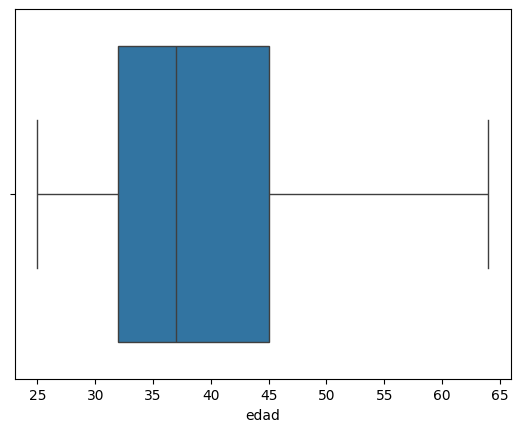

In [ ]:
# Inspección visual: en el análisis inicial hemos visto que la variable Edad tenía outlier
sns.boxplot(data=df, x='edad')
plt.show()

 ### Conclusión: El outlier que antes teniamos en el gráfico de 'Edad' ha desaparecido cuando hemos eliminado la categoria de becarios.

<Axes: >

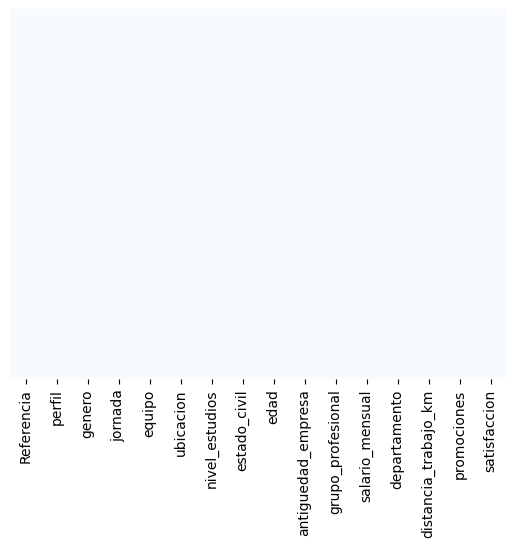

In [ ]:
# Comprobamos si nos faltan datos -> Afortunadamente no es así
sns.heatmap(df_procesado.isnull(), yticklabels=False, cbar=False, cmap = "Blues")

array([[<Axes: title={'center': 'perfil'}>,
        <Axes: title={'center': 'genero'}>,
        <Axes: title={'center': 'jornada'}>],
       [<Axes: title={'center': 'ubicacion'}>,
        <Axes: title={'center': 'nivel_estudios'}>,
        <Axes: title={'center': 'edad'}>],
       [<Axes: title={'center': 'antiguedad_empresa'}>,
        <Axes: title={'center': 'grupo_profesional'}>,
        <Axes: title={'center': 'salario_mensual'}>],
       [<Axes: title={'center': 'distancia_trabajo_km'}>,
        <Axes: title={'center': 'promociones'}>,
        <Axes: title={'center': 'satisfaccion'}>]], dtype=object)

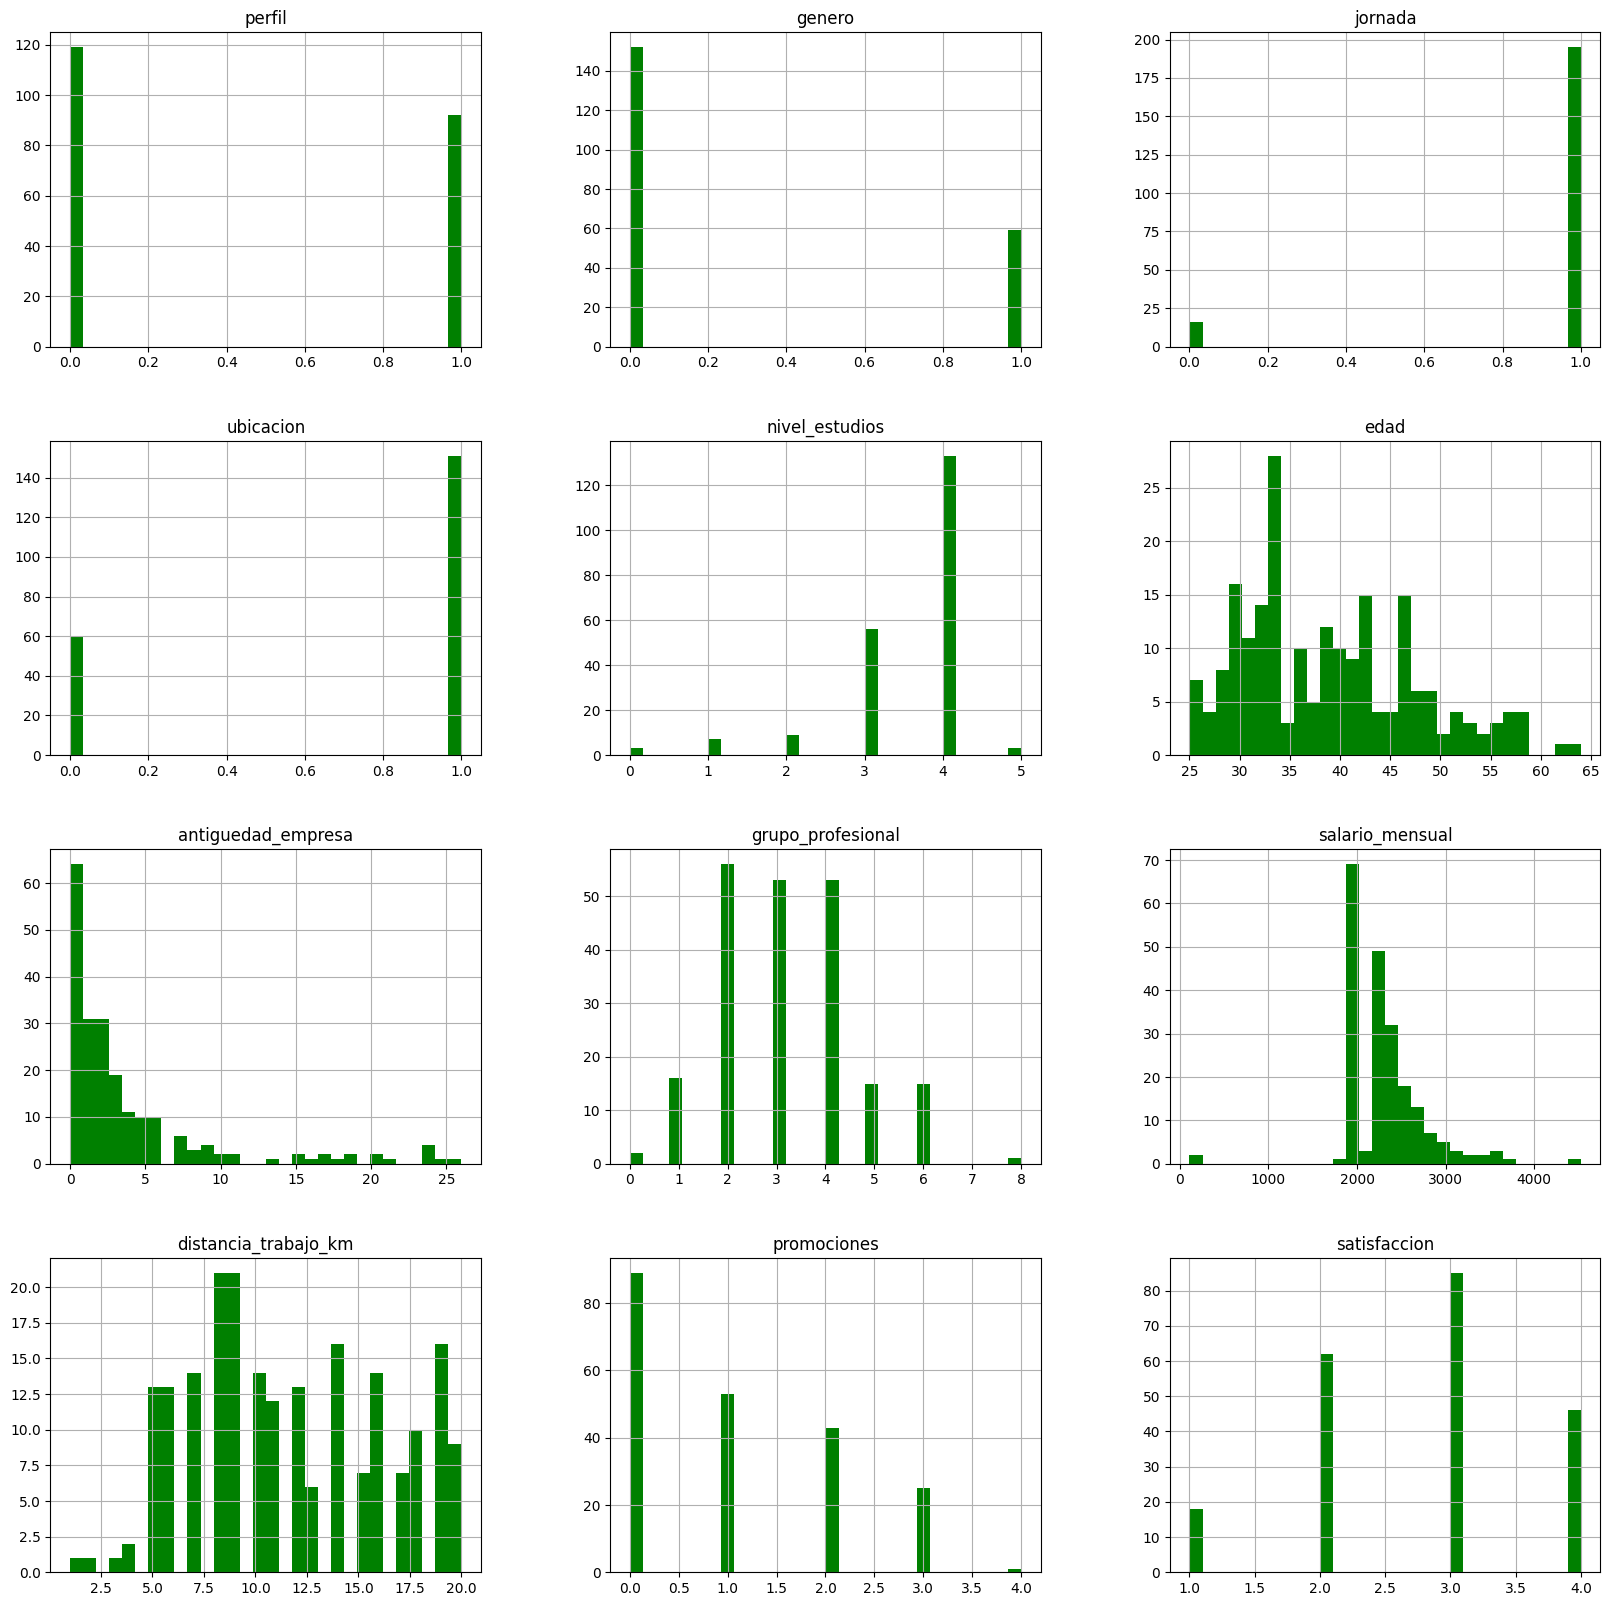

In [ ]:
df_procesado.hist(bins = 30, figsize = (20, 20), color = 'g')

#3. Generación de Insights

In [ ]:
# Comprobamos cuantos empleados abandonan la empresa
left_df = df_procesado[df_procesado['perfil'] == 0]  # Empleados que abandonan la empresa
stayed_df = df_procesado[df_procesado['perfil'] == 1] # Empleados que permanecen en la empresa

In [ ]:
# Contamos el número de empleados que se quedaron y que se fueron
print("Total = ", len(df_procesado))

print("Número de empleados que dejan la empresa = ", len(left_df))
print("Porcentaje de empleados que dejan la empresa = ", 1.*len(left_df)/len(df_procesado)*100.0, "%")

print("Número de empleados que permanecen en la empresa = ", len(stayed_df))
print("Porcentaje de empleados que se quedan en la empresa = ", 1.*len(stayed_df)/len(df_procesado)*100.0, "%")

Total =  211
Número de empleados que dejan la empresa =  119
Porcentaje de empleados que dejan la empresa =  56.39810426540285 %
Número de empleados que permanecen en la empresa =  92
Porcentaje de empleados que se quedan en la empresa =  43.60189573459716 %


In [ ]:
# Calculamos la Tasa de abandono y utilizamos"normalize = True" para obtener el porcentaje de nuestra varibale target (perfil)
df['perfil'].value_counts(normalize= True)*100

,proportion
perfil,
No activo,56.398104
Activo,43.601896


In [ ]:
# estadisticas de los empleados que abandonan la empresa
left_df.describe()

,perfil,genero,jornada,ubicacion,nivel_estudios,edad,antiguedad_empresa,grupo_profesional,salario_mensual,distancia_trabajo_km,promociones,satisfaccion
count,119.0,119.000000,119.00000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,0.0,0.319328,0.89916,0.731092,3.521008,38.655462,1.453782,2.596639,2146.941176,12.495798,0.638655,2.420168
std,0.0,0.468188,0.30239,0.445267,0.757435,8.646972,2.227516,1.083930,198.555132,4.652089,0.767243,0.858613
min,0.0,0.000000,0.00000,0.000000,0.000000,26.000000,0.000000,1.000000,1930.000000,5.000000,0.000000,1.000000
25%,0.0,0.000000,1.00000,0.000000,3.000000,32.000000,0.000000,2.000000,2012.000000,8.000000,0.000000,2.000000
50%,0.0,0.000000,1.00000,1.000000,4.000000,36.000000,1.000000,2.000000,2012.000000,12.000000,0.000000,2.000000
75%,0.0,1.000000,1.00000,1.000000,4.000000,43.000000,2.000000,3.000000,2195.000000,16.000000,1.000000,3.000000
max,0.0,1.000000,1.00000,1.000000,5.000000,64.000000,15.000000,6.000000,2782.000000,20.000000,3.000000,4.000000


In [ ]:
# estadisticas de los empleados que se quedaron
stayed_df.describe()

,perfil,genero,jornada,ubicacion,nivel_estudios,edad,antiguedad_empresa,grupo_profesional,salario_mensual,distancia_trabajo_km,promociones,satisfaccion
count,92.0,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.00000,92.000000,92.000000,92.000000
mean,1.0,0.228261,0.956522,0.695652,3.489130,38.945652,6.869565,3.945652,2535.23913,10.510870,1.543478,3.184783
std,0.0,0.422011,0.205049,0.462652,0.977714,8.668960,7.055848,1.369721,575.05408,4.620771,1.189820,0.740201
min,1.0,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,0.000000,108.00000,1.000000,0.000000,1.000000
25%,1.0,0.000000,1.000000,0.000000,3.000000,31.000000,2.000000,3.000000,2204.25000,7.000000,0.000000,3.000000
50%,1.0,0.000000,1.000000,1.000000,4.000000,39.500000,4.000000,4.000000,2515.00000,9.000000,2.000000,3.000000
75%,1.0,0.000000,1.000000,1.000000,4.000000,46.000000,9.000000,5.000000,2753.50000,14.000000,3.000000,4.000000
max,1.0,1.000000,1.000000,1.000000,5.000000,58.000000,26.000000,8.000000,4528.00000,20.000000,4.000000,4.000000


###Conclusiones:

*   edad: La edad media de los empleados que se quedaron es mayor en comparación con los que fueron
*   antiguedad_empresa: la antiguedad media de los empleados que se quedaron es mayor en comparación con los que fueron
*   salario_mensual: el salario medio de los empleados que se quedaron es mayor en comparación con los que se fueron
*   distancia_trabajo_km: los empleados que se quedan viven más cerca del trabajo
*   promociones: la media de las promociones salariales de empleados que se quedaron es mayor en comparación con los que fueron
*   satisfacción: los empleados que se quedan están en general más satisfechos con sus trabajo



<Axes: xlabel='antiguedad_empresa', ylabel='count'>

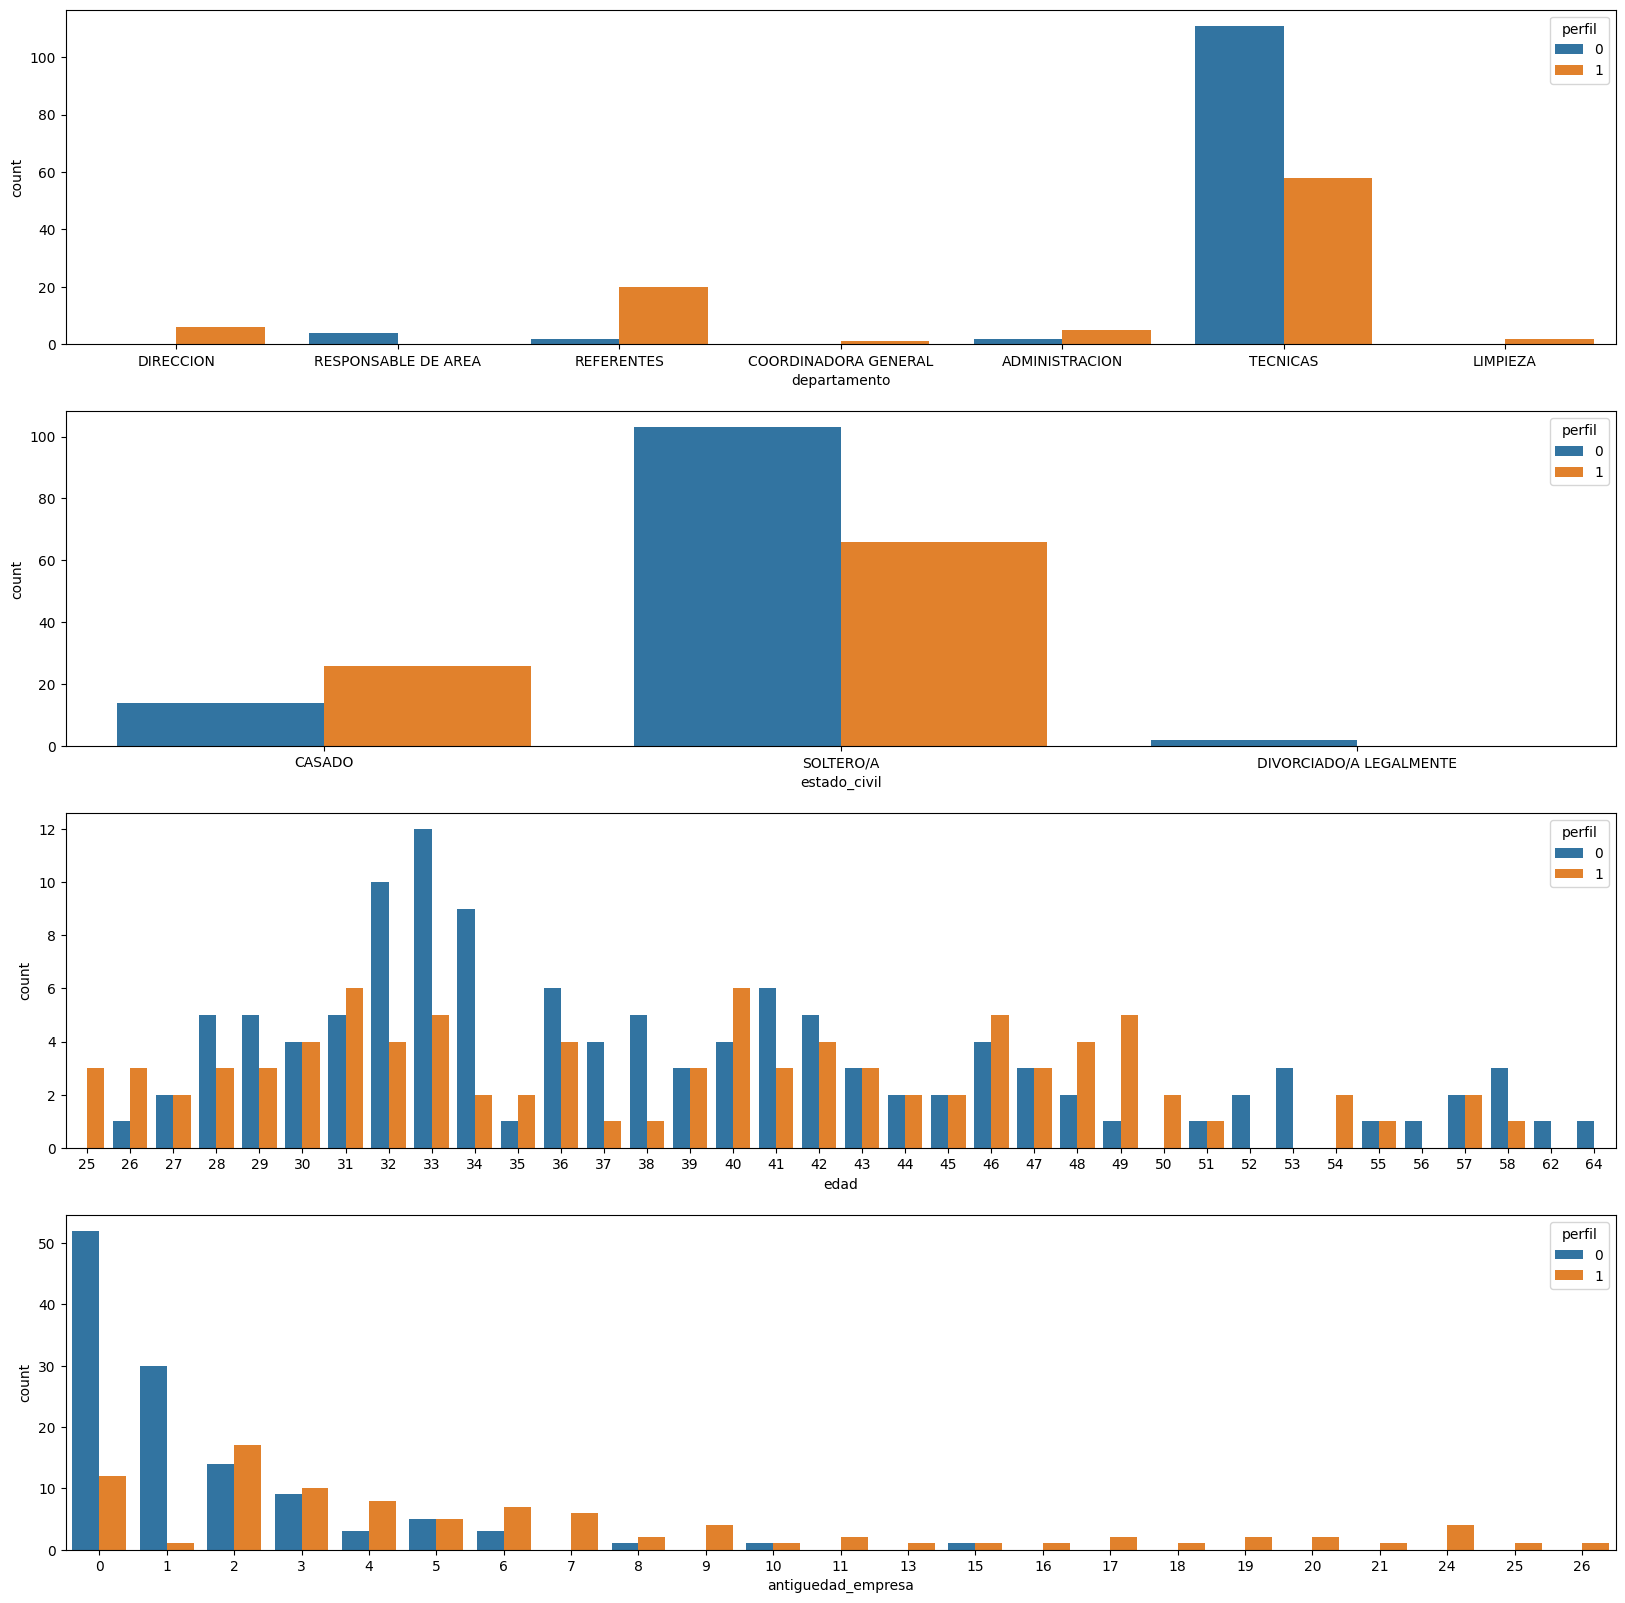

In [ ]:
plt.figure(figsize=[20,20])
plt.subplot(411)
sns.countplot(x = 'departamento', hue = 'perfil', data = df_procesado)
plt.subplot(412)
sns.countplot(x = 'estado_civil', hue = 'perfil', data = df_procesado)
plt.subplot(413)
sns.countplot(x = 'edad', hue = 'perfil', data = df_procesado)
plt.subplot(414)
sns.countplot(x = 'antiguedad_empresa', hue = 'perfil', data = df_procesado)


# Los tecnicos y tecnicas tienden a irse en comparación con cualquier otro departamento
# Los empleados solteros tienden a irse en comparación con los casados ​​y divorciados
# Los empleados entre 28 y 38 años tienen a dejar la empresa
# Los menos experimentados (menos antiguedad) tienden a dejar la empresa

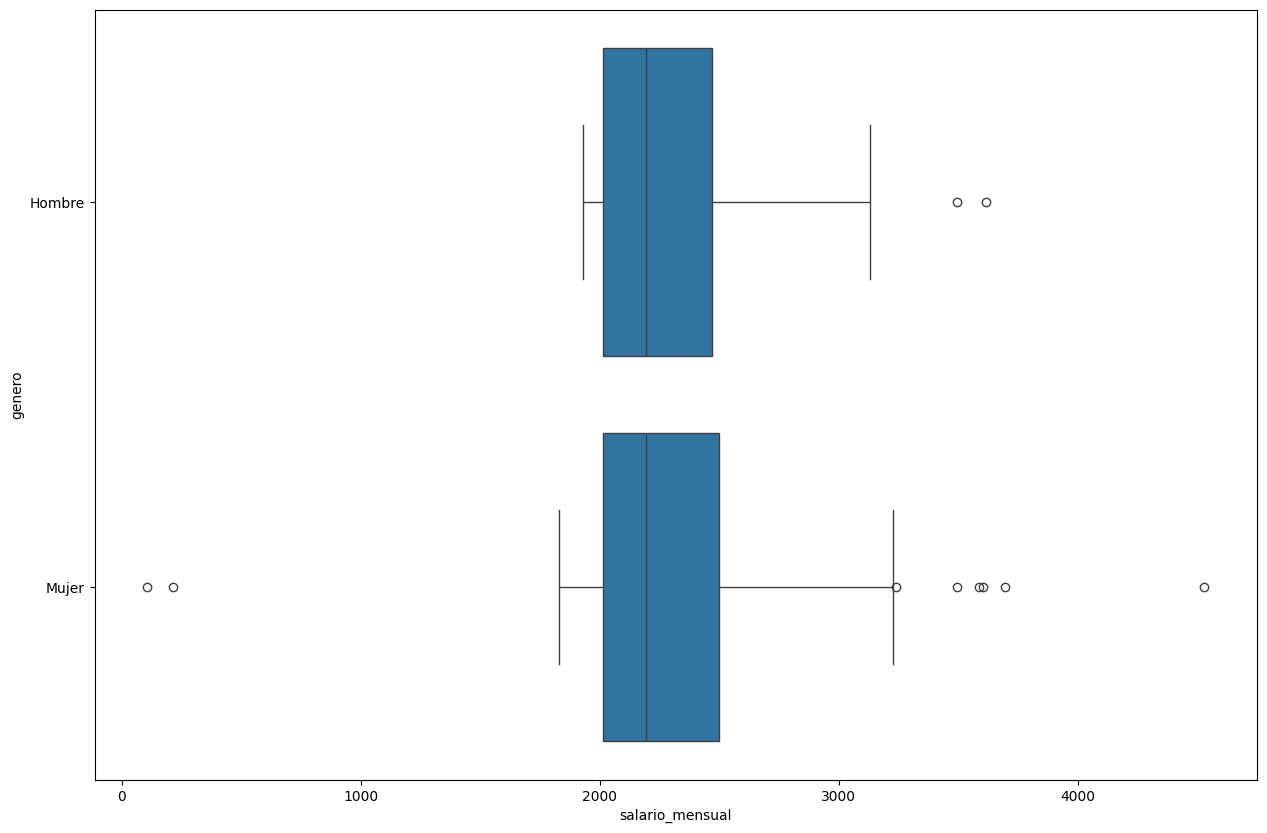

In [ ]:
# veamos el género vs el ingreso mensual
plt.figure(figsize=(15, 10))
sns.boxplot(x = 'salario_mensual', y = 'genero', data = df)
plt.show()

<Axes: xlabel='salario_mensual', ylabel='departamento'>

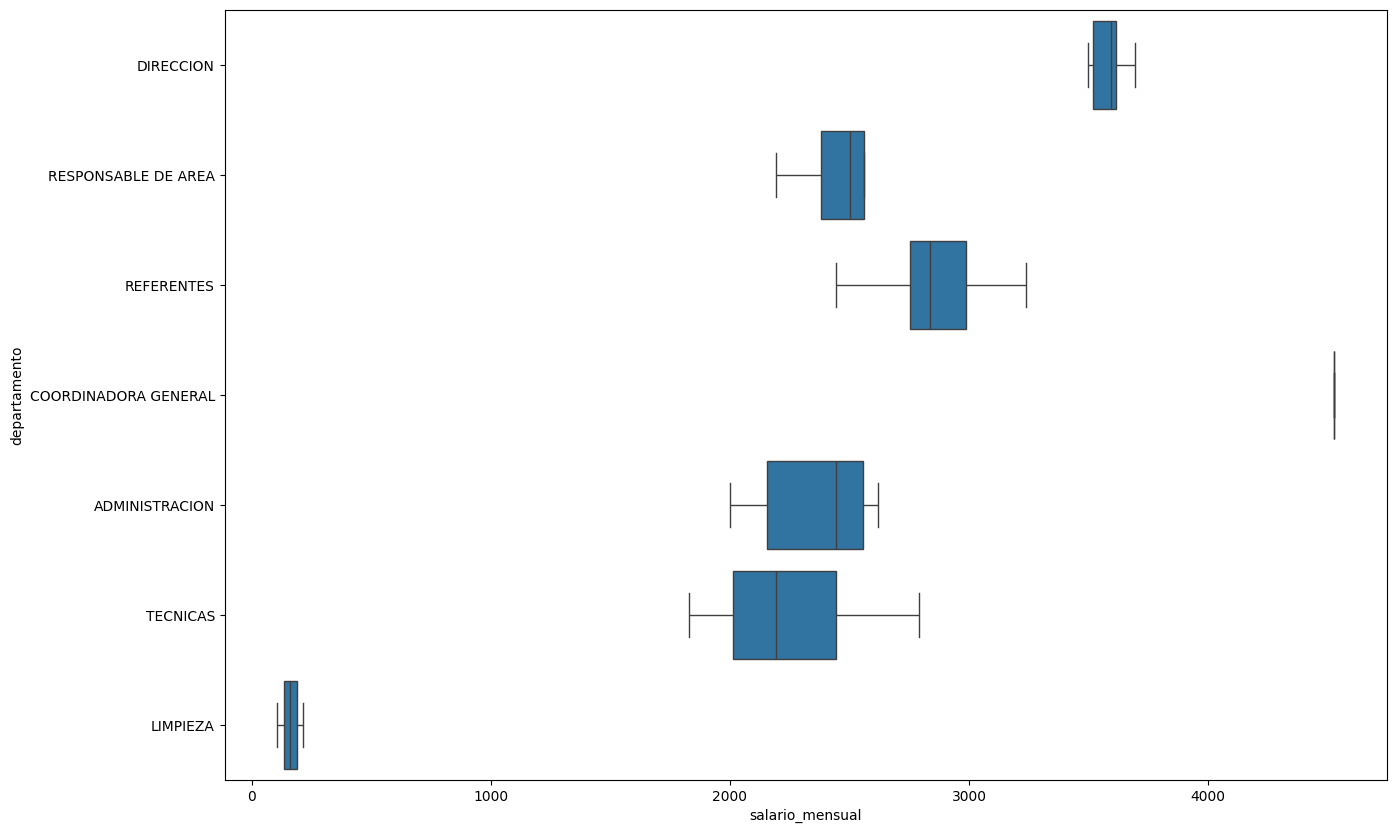

In [ ]:
# Veamos el ingreso mensual con la categoria
plt.figure(figsize=(15, 10))
sns.boxplot(x = 'salario_mensual', y = 'departamento', data = df_procesado)

<Axes: >

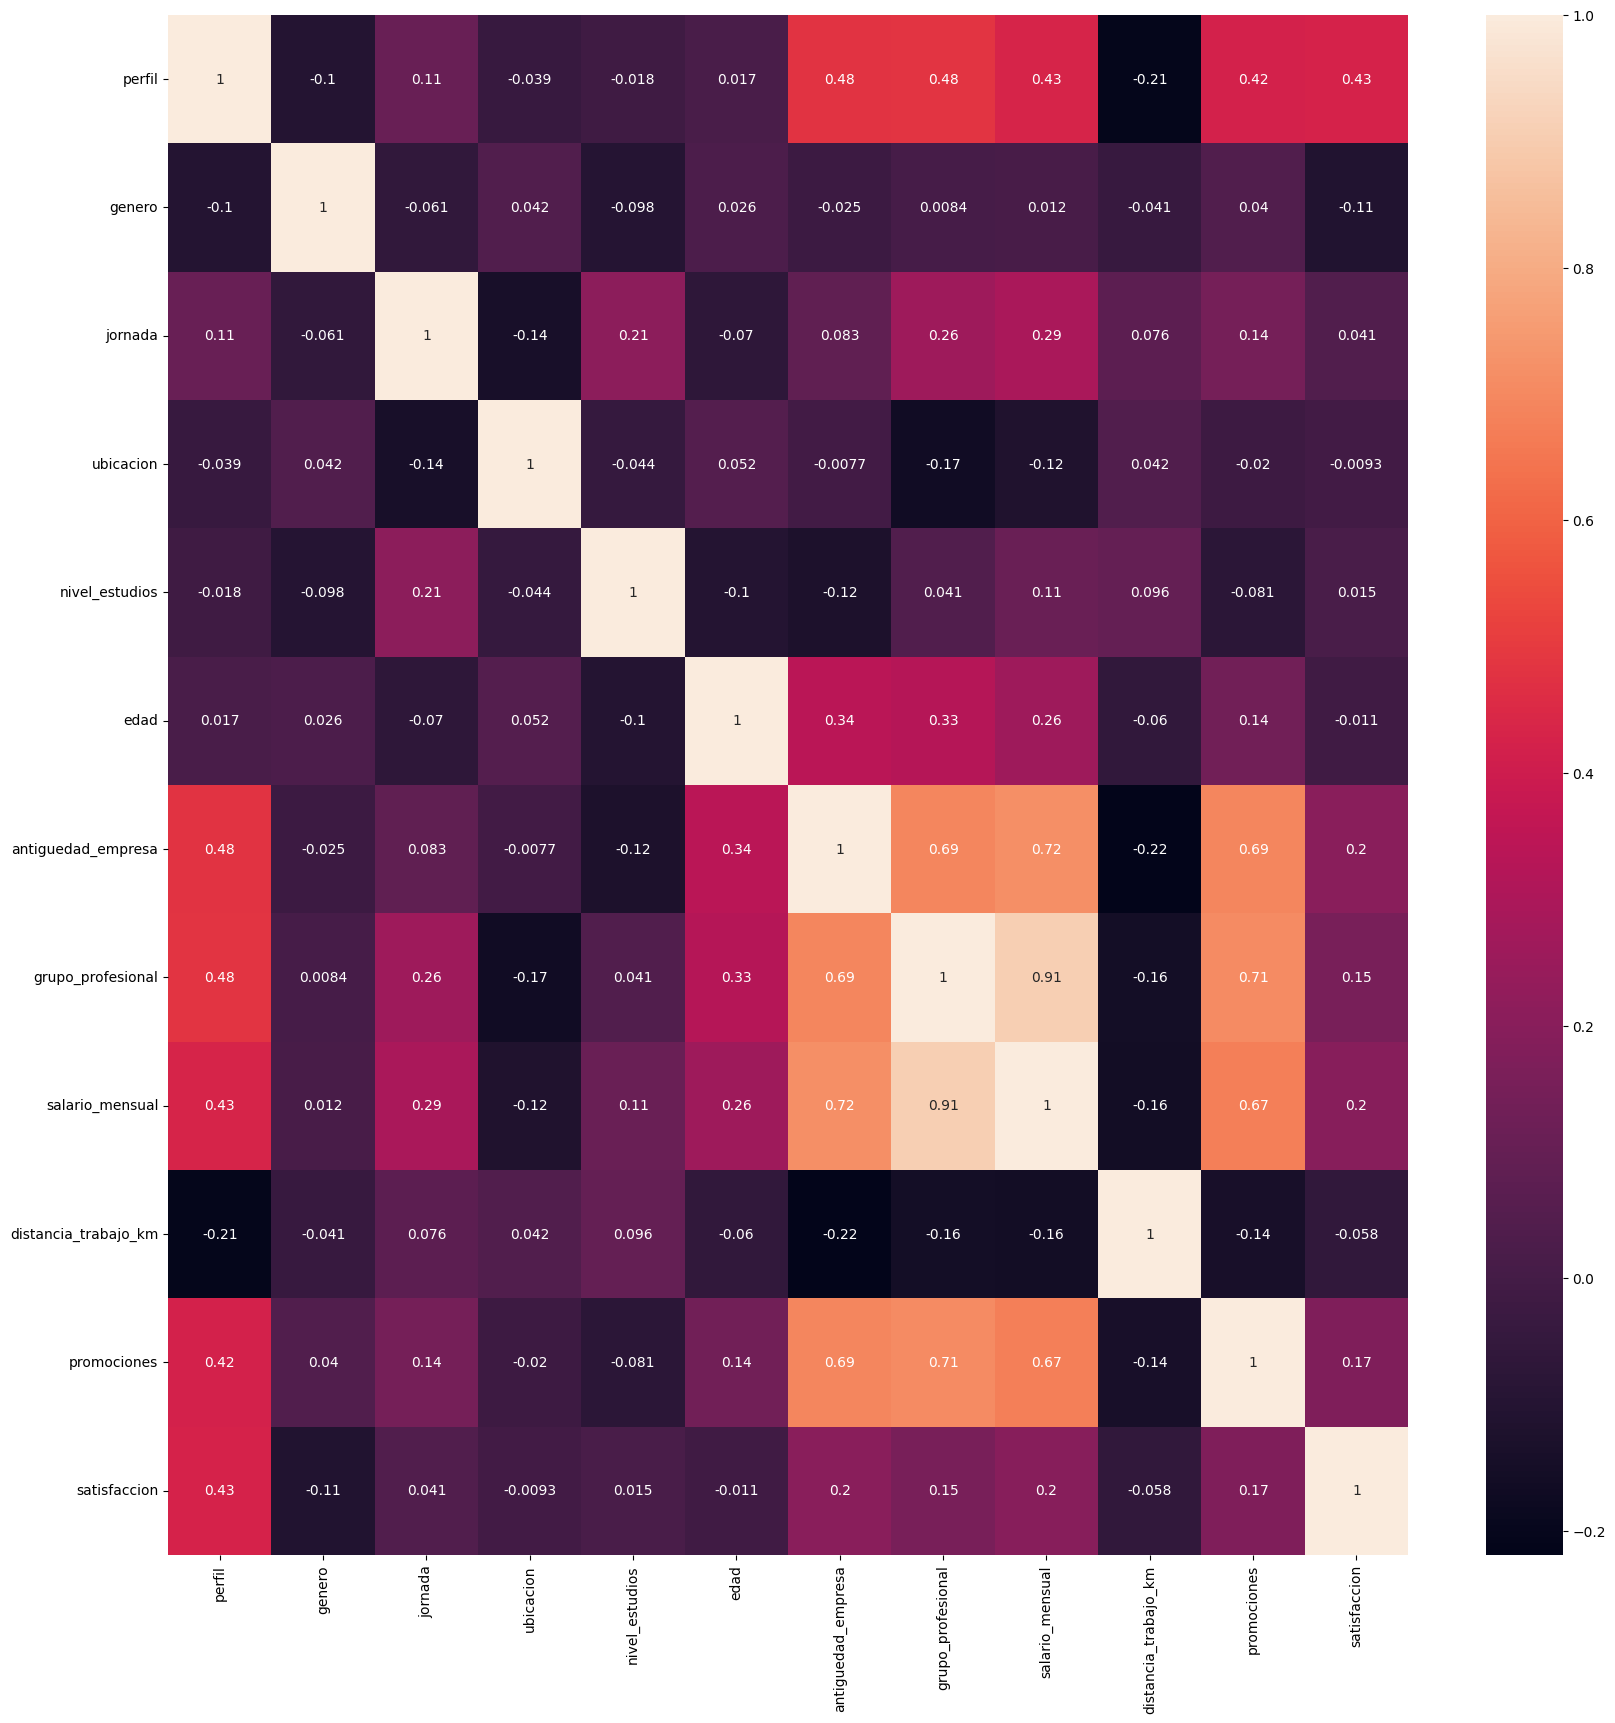

In [ ]:
# Estudiamos las correlaciones entre las variables (mapa de calor de correlaciones)

correlations = df_procesado.select_dtypes(include='number').corr()

f, ax = plt.subplots(figsize = (20,20))
sns.heatmap(correlations, annot=True)

###Conclusiones de las variables más correlacionadas con la variable objetivo (perfil):
* grupo_profesional (0.48) -> Empleados con mejor grupo profesional tienden a
quedarse.
* salario_mensual (0.43) -> A mayor salario, menor probabilidad de abandonar la empresa.
* satisfacción (0.43) -> La satisfacción tiene un impacto en la permanecia
* promociones (0.42) -> Recibir promociones se asocia con menor rotación
* antiguedad_empresa (0.48) -> Más antiguedad suele significar mayor lealtal o menor intención de rotación.

#4. ¿Cuál es el impacto económico de este problema?

In [ ]:
# Primero: tenemos el salario/mes, tenemos que recodificarlo a salario/año
df_procesado['salario_anual'] = df_procesado['salario_mensual'].transform(lambda x: x*12)

df_procesado[['salario_mensual', 'salario_anual']].head()

,salario_mensual,salario_anual
0,3617,43404
1,2562,30744
2,3605,43260
3,3696,44352
4,3228,38736


###Según el siguiente articulo: https://toggl.com/blog/cost-of-hiring-an-employee las empresas destinan entre un 15% y 20% del salario anual del empleado para contratar a un nuevo candidato

In [ ]:
# Segundo: Tomaremos de referencia que la media que destina la empresa en contratar a alguien será del 20%

# Calculamos el impacto económico como el 20% del salario anual usando transform
df_procesado['impacto_abandono'] = df_procesado['salario_anual'].transform(lambda x: x * 0.20)

# Mostramos las columnas relevantes para verificar
df_procesado[['salario_mensual', 'salario_anual', 'impacto_abandono']].head()


,salario_mensual,salario_anual,impacto_abandono
0,3617,43404,8680.8
1,2562,30744,6148.8
2,3605,43260,8652.0
3,3696,44352,8870.4
4,3228,38736,7747.2


In [ ]:
# ¿Cúanto nos ha costado este problema en estos últimos años? (coste total)
coste_total = df_procesado[df_procesado['perfil'] == 0]['impacto_abandono'].sum()
print("Coste total = ", coste_total)

Coste total =  613166.4000000004


##4.1 ¿Cuanto dinero podriamos ahorrar reteniendo mejor a nuestros empleados?
###Creamos varios escenarios de ahorro. Por ejemplo: reducir un 10%, 20% y 30% de abandono

In [ ]:
print(
    f'\nReducir un 10% la fuga de empleados nos ahorra {int(coste_total * 0.1)}€ cada año.\n'
    f'Reducir un 20% la fuga de empleados nos ahorra {int(coste_total * 0.2)}€ cada año.\n'
    f'Reducir un 30% la fuga de empleados nos ahorra {int(coste_total * 0.3)}€ cada año.\n'
)


Reducir un 10% la fuga de empleados nos ahorra 61316€ cada año.
Reducir un 20% la fuga de empleados nos ahorra 122633€ cada año.
Reducir un 30% la fuga de empleados nos ahorra 183949€ cada año.



In [ ]:
df_procesado

,Referencia,perfil,genero,jornada,equipo,ubicacion,nivel_estudios,estado_civil,edad,antiguedad_empresa,grupo_profesional,salario_mensual,departamento,distancia_trabajo_km,promociones,satisfaccion,salario_anual,impacto_abandono
0,TRB-0000002,1,1,1,SEVILLA,1,1.0,CASADO,46,25,6.0,3617,DIRECCION,10,3,4,43404,8680.8
1,TRB-0000005,0,0,1,SEVILLA,1,4.0,CASADO,48,10,5.0,2562,RESPONSABLE DE AREA,14,2,2,30744,6148.8
2,TRB-0000007,1,0,1,ADMINISTRACION,1,4.0,CASADO,50,24,6.0,3605,DIRECCION,6,3,3,43260,8652.0
3,TRB-0000008,1,0,1,ORIENTE MEDIO,0,3.0,SOLTERO/A,50,24,6.0,3696,DIRECCION,8,3,3,44352,8870.4
4,TRB-0000009,1,0,1,MADRID,1,4.0,SOLTERO/A,48,24,6.0,3228,REFERENTES,9,3,3,38736,7747.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,TRB-0000243,1,0,1,EL SALVADOR,0,4.0,SOLTERO/A,27,0,2.0,2024,TECNICAS,12,0,3,24288,4857.6
219,TRB-0000246,1,0,1,EUSKADI,1,4.0,SOLTERO/A,29,0,2.0,2114,TECNICAS,10,0,3,25368,5073.6
220,TRB-0000247,1,0,1,BARCELONA,1,3.0,SOLTERO/A,25,0,2.0,2012,TECNICAS,14,0,4,24144,4828.8
221,TRB-0000248,1,0,1,VALENCIA,1,4.0,SOLTERO/A,30,0,3.0,2186,TECNICAS,8,0,3,26232,5246.4


In [ ]:
# descargar dataset en csv
#df_procesado.to_csv('df_procesado_empleados.csv', index=False)